In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as patches

In [50]:
alphas = [0.2, 0.4, 0.6, 0.8]
gammas = [0.6, 0.7, 0.8, 0.9]

In [51]:
maxcost = pd.read_csv(f'alpha02_gamma06/results/evaluation.csv')['Stage 0'].median()

In [52]:
best_cost = []
for a in alphas:
    best_cost.append([])
    for g in gammas:
        astr = str(a).replace('.', '')
        gstr = str(g).replace('.', '')
        C = pd.read_csv(f'alpha{astr}_gamma{gstr}/results/evaluation.csv').median().min()
        best_cost[-1].append(((maxcost - C) / maxcost) * 100)

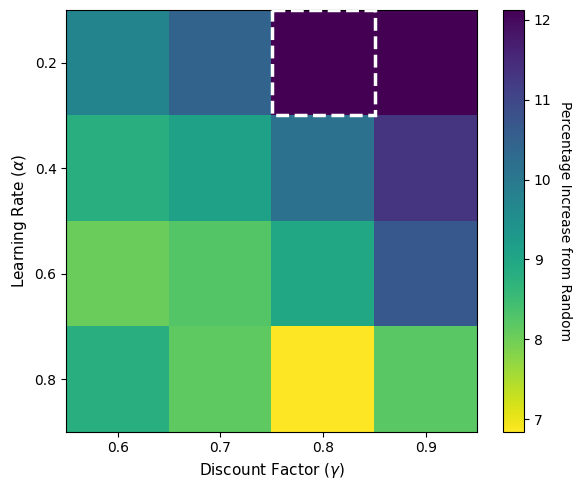

In [54]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(best_cost, cmap="viridis_r", aspect="auto")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Percentage Increase from Random", rotation=270, labelpad=15)
ax.set_xticks(np.arange(len(gammas)))
ax.set_yticks(np.arange(len(alphas)))
ax.set_xticklabels([f"{g:.1f}" for g in gammas])
ax.set_yticklabels([f"{a:.1f}" for a in alphas])
ax.set_xlabel(r"Discount Factor ($\gamma$)", fontsize=11)
ax.set_ylabel(r"Learning Rate ($\alpha$)", fontsize=11)

rect = patches.Rectangle(
    (1.5, -0.5),  # (x_min, y_min) in grid coordinates
    1.0,  # width (0.75 -> 0.85)
    1.0,  # height (0.10 -> 0.30)
    linewidth=2.5,
    edgecolor="white",
    facecolor="none",
    linestyle="--",
    zorder=5,
)
ax.add_patch(rect)

plt.tight_layout()
plt.show()